# Antes de sembrar la primera semilla, el mundo hablaba **menos** idiomas que hoy

Hace unos 12.000 años, justo antes de que empezáramos a domesticar plantas y animales, el planeta tenía entre **4.500 y 6.000 lenguas**. Hoy son unas 7.500. Menos, no más — y el salto no es "el doble", es apenas 1,4 veces.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

Un equipo cruzó modelado estadístico, datos de 339 sociedades cazadoras-recolectoras y paleodemografía —cuánta gente vivía en cada época— para estimar cuántas lenguas cabían en el mundo antes de la agricultura. Abrimos sus datos y reconstruimos las piezas que se pueden reproducir.

**Paper:** Blasi, Hamilton, Gray & Bowern (2026). *The rise and fall of language diversity through the Holocene*. **Science**.  
**DOI:** [10.1126/science.adx4343](https://doi.org/10.1126/science.adx4343)  
**Datos:** [OSF · 10.17605/OSF.IO/NEUTV](https://doi.org/10.17605/OSF.IO/NEUTV)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-23-lenguas-diversidad-holoceno/notebook.ipynb)

**Video:** _(pendiente)_

## De qué va esto

Nadie grabó cuántas lenguas se hablaban hace 12.000 años. El equipo lo **estima** con un modelo: parte de cuántas lenguas por persona se ven hoy en sociedades cazadoras-recolectoras (339 grupos de la base de Binford), y proyecta hacia atrás usando cuánta gente había en cada momento.

Como es una **estimación de modelo**, cada número viene con una nube de incertidumbre. Por eso el hallazgo no es un punto exacto: es un **rango**. Y ese rango, veremos, es lo interesante.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
VALOR_ANTES   = 5317           # mediana de lenguas antes de domesticacion (nuestro calculo)
VALOR_HOY     = 7500           # lenguas hoy (cifra del paper)
RANGO_ANTES   = (4500, 6000)   # rango que reporta el paper
FUENTE        = 'Fuente: Blasi et al. (2026), Science | Datos: OSF (10.17605/OSF.IO/NEUTV)'
COLOR_DATOS       = '#2563EB'
COLOR_ALERTA      = '#DC2626'
COLOR_REFERENCIA  = '#D97706'
COLOR_SECUNDARIO  = '#059669'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

def mil(n):
    # separador de miles en espanol: punto
    return f'{n:,.0f}'.replace(',', '.')

# Carga de datos
eh  = pd.read_csv('datos/early_holocene_languages.csv')
sc  = pd.read_csv('datos/scenarios_summary.csv')
pop = pd.read_csv('datos/global_population.csv')
fpca = pd.read_csv('datos/fpca_variance.csv')

med_global = eh['n_languages'].median()
iqr = (eh['n_languages'].quantile(.25), eh['n_languages'].quantile(.75))
print(f'Estimaciones (draws Monte-Carlo): {len(eh):,}'.replace(',', '.'))
print(f'Escenarios de modelado: {eh["id"].nunique()}')
print(f'Mediana global de lenguas ~12 kybp: {mil(med_global)}')
print(f'Rango intercuartil (50% central): {mil(iqr[0])} - {mil(iqr[1])}')
print(f'Medianas por escenario: de {mil(sc.median_langs.min())} a {mil(sc.median_langs.max())}')
print(f'Población global -10000 -> 2017: {mil(pop.pop_mid.iloc[0])} -> {mil(pop.pop_mid.iloc[-1])} personas')
print(f'PC1 (FPCA) explica {fpca.cumulative_variance.iloc[0]*100:.1f}% de la forma temporal')

Estimaciones (draws Monte-Carlo): 21.600
Escenarios de modelado: 8
Mediana global de lenguas ~12 kybp: 5.317
Rango intercuartil (50% central): 4.540 - 6.183
Medianas por escenario: de 3.980 a 6.053
Población global -10000 -> 2017: 4.432.264 -> 7.406.623.853 personas
PC1 (FPCA) explica 75.5% de la forma temporal


## Aquí está.

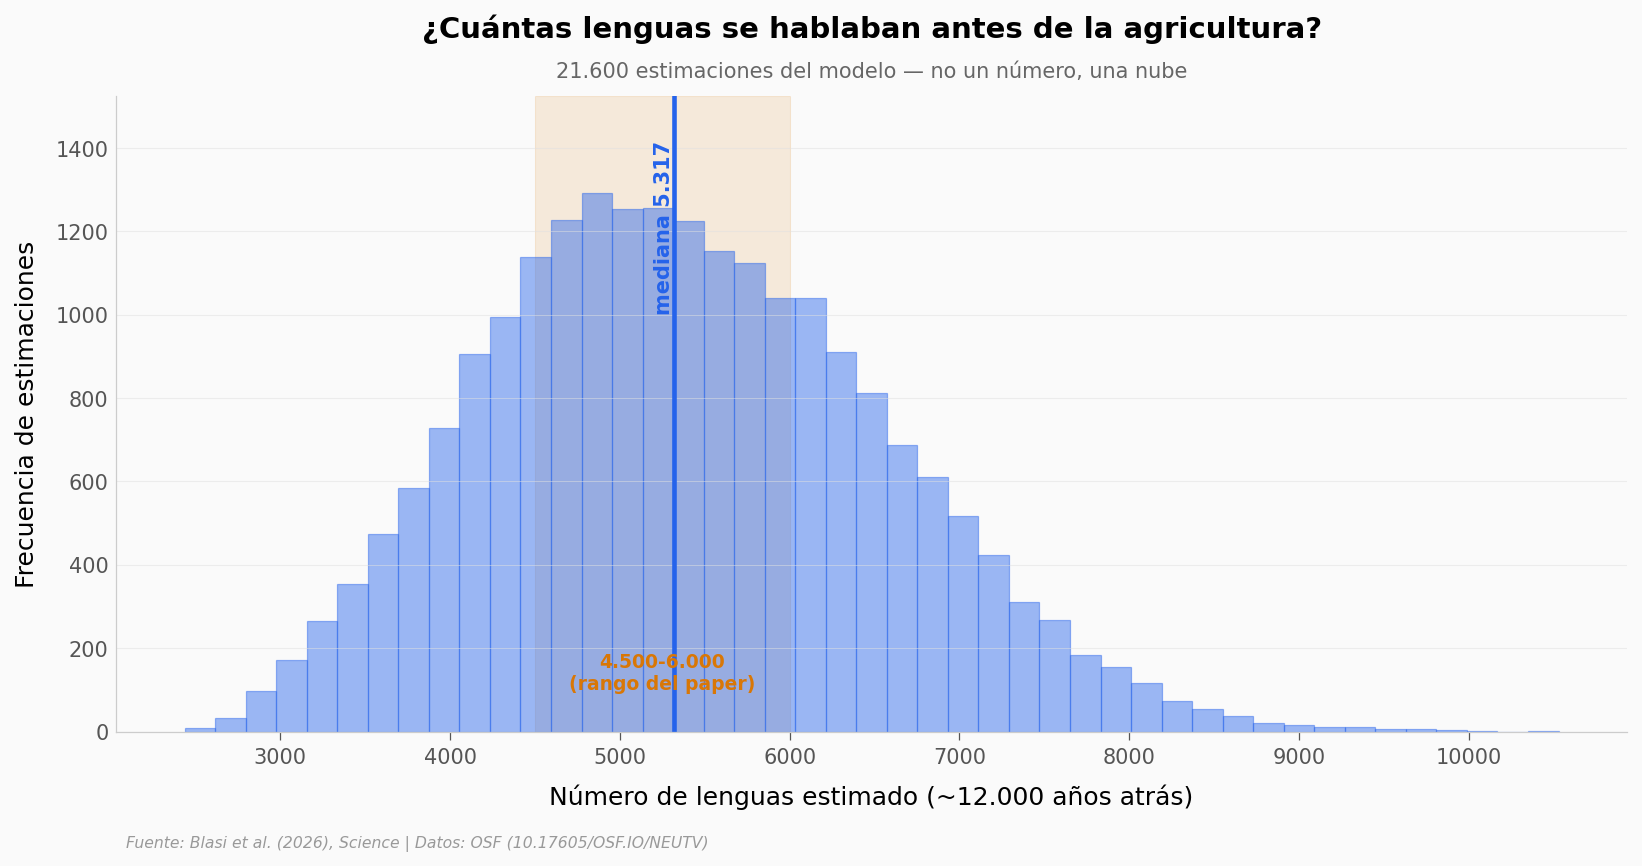

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
data = eh['n_languages']
n, bins, patches = ax.hist(data, bins=45, color=COLOR_DATOS, alpha=0.45,
                           edgecolor=COLOR_DATOS, linewidth=0.6)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Banda del rango que reporta el paper
ax.axvspan(RANGO_ANTES[0], RANGO_ANTES[1], color=COLOR_REFERENCIA, alpha=0.13, zorder=0)
ax.text((RANGO_ANTES[0]+RANGO_ANTES[1])/2, y_max*0.06,
        f'{mil(RANGO_ANTES[0])}-{mil(RANGO_ANTES[1])}\n(rango del paper)',
        ha='center', va='bottom', fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')

# Mediana global
ax.axvline(med_global, color=COLOR_DATOS, linewidth=2.2)
ax.text(med_global, y_max*0.93, f'mediana {mil(med_global)}',
        rotation=90, va='top', ha='right', fontsize=10,
        color=COLOR_DATOS, fontweight='bold')

ax.set_title('¿Cuántas lenguas se hablaban antes de la agricultura?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '21.600 estimaciones del modelo — no un número, una nube',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Número de lenguas estimado (~12.000 años atrás)')
ax.set_ylabel('Frecuencia de estimaciones')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_lenguas.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención: **no es un número, es una nube ancha.** El modelo no dice "había X lenguas" — dice "lo más probable es que hubiera entre 4.500 y 6.000, con la mitad central de las estimaciones entre 4.540 y 6.183". Esa anchura no es un defecto: es la honestidad del método. Estamos reconstruyendo un mundo sin registros.

Y aun con toda esa incertidumbre, la mediana (5.317) queda **por debajo** de las ~7.500 lenguas de hoy.

## ¿Y si el modelo estuviera inflando el rango?

Buena sospecha. El equipo la probó: corrió el cálculo de **8 formas distintas** — dos maneras de describir la incertidumbre (weibull / lognormal), dos cotas superiores (estrecha / amplia) y con o sin ponderar. Si las 8 medianas quedan cerca del rango 4.500-6.000, es robusto. Veamos.

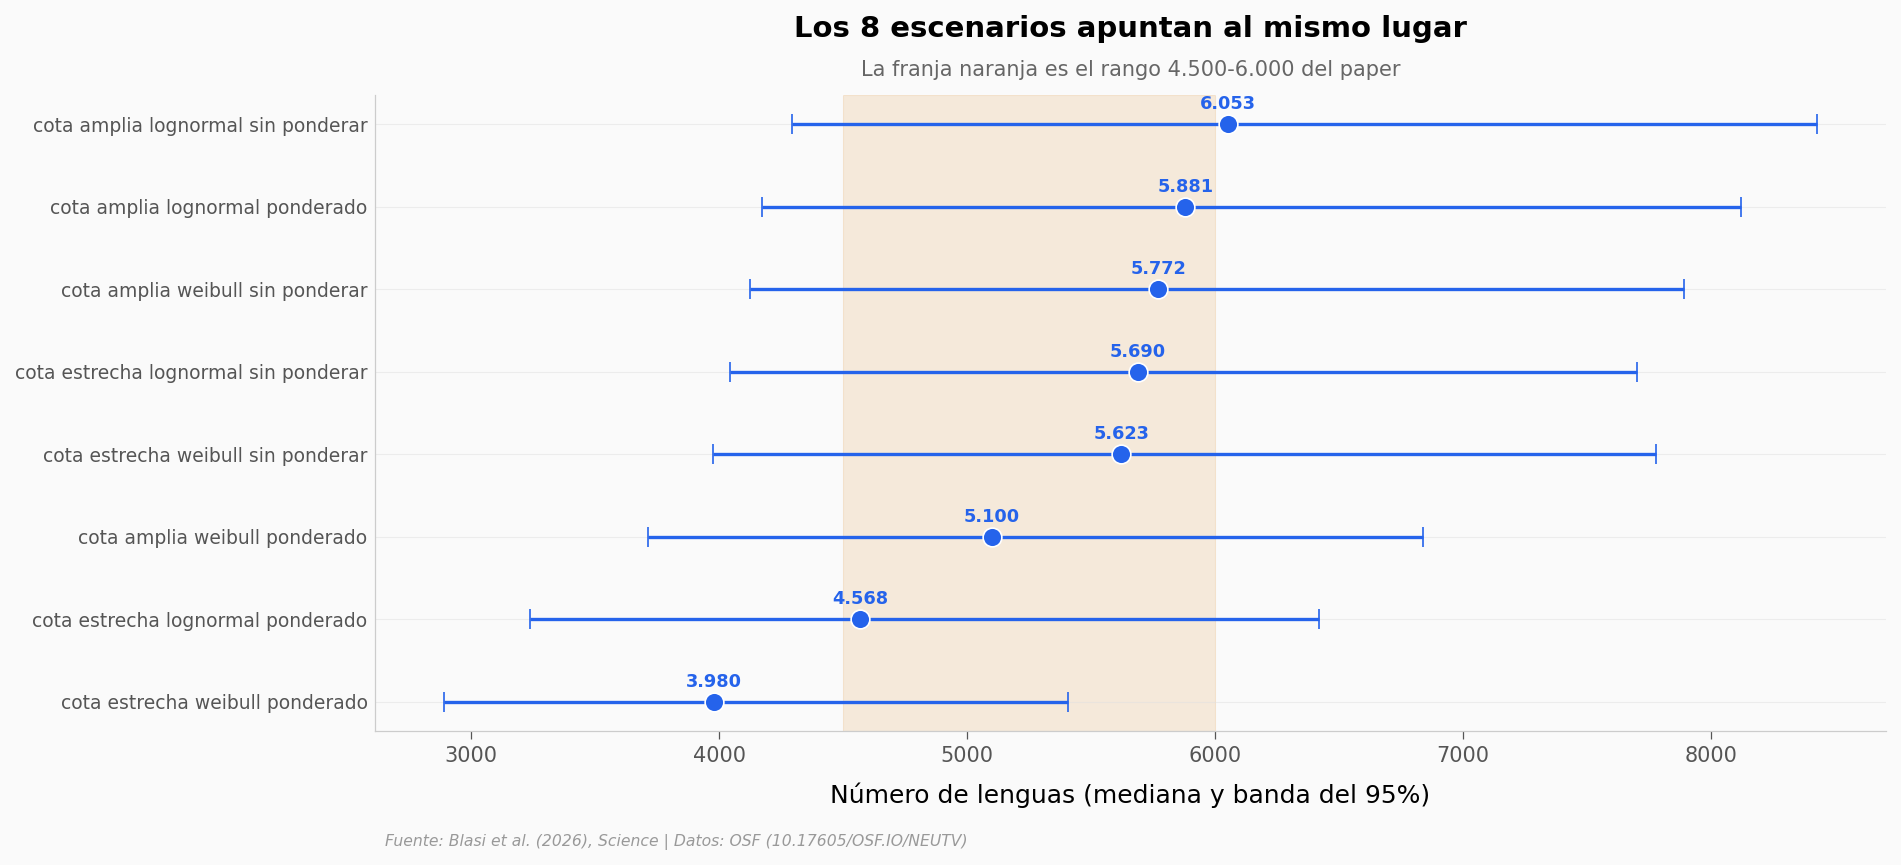

In [3]:
# Traducir los nombres de escenario a algo legible
def traducir(nombre):
    t = nombre.replace('tight', 'cota estrecha').replace('loose', 'cota amplia')
    t = t.replace('unweighted', 'sin ponderar').replace('weighted', 'ponderado')
    return t

sc_ord = sc.sort_values('median_langs').reset_index(drop=True)
ypos = np.arange(len(sc_ord))
xerr = np.array([sc_ord.median_langs - sc_ord.ci_low,
                 sc_ord.ci_high - sc_ord.median_langs])

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axvspan(RANGO_ANTES[0], RANGO_ANTES[1], color=COLOR_REFERENCIA, alpha=0.13, zorder=0)
ax.errorbar(sc_ord.median_langs, ypos, xerr=xerr, fmt='o',
            color=COLOR_DATOS, ecolor=COLOR_DATOS, elinewidth=1.6,
            capsize=5, capthick=1.5, markersize=9, markeredgecolor='white',
            markeredgewidth=0.8, zorder=5)
for i, row in sc_ord.iterrows():
    ax.text(row.median_langs, i + 0.18, mil(row.median_langs),
            ha='center', fontsize=8.5, color=COLOR_DATOS, fontweight='bold')
ax.set_yticks(ypos)
ax.set_yticklabels([traducir(x) for x in sc_ord.id], fontsize=9)
ax.set_xlabel('Número de lenguas (mediana y banda del 95%)')
ax.set_title('Los 8 escenarios apuntan al mismo lugar',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La franja naranja es el rango 4.500-6.000 del paper',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/escenarios_robustez.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué hizo subir el número desde entonces?

El modelo ata la diversidad de lenguas a **cuánta gente hay**. Y ahí pasó algo enorme: entre el final de la última glaciación y hoy, la población mundial no creció un poco — se multiplicó. Ese es el motor que el paper asocia (no "causa" — es un modelo) con el aumento de lenguas.

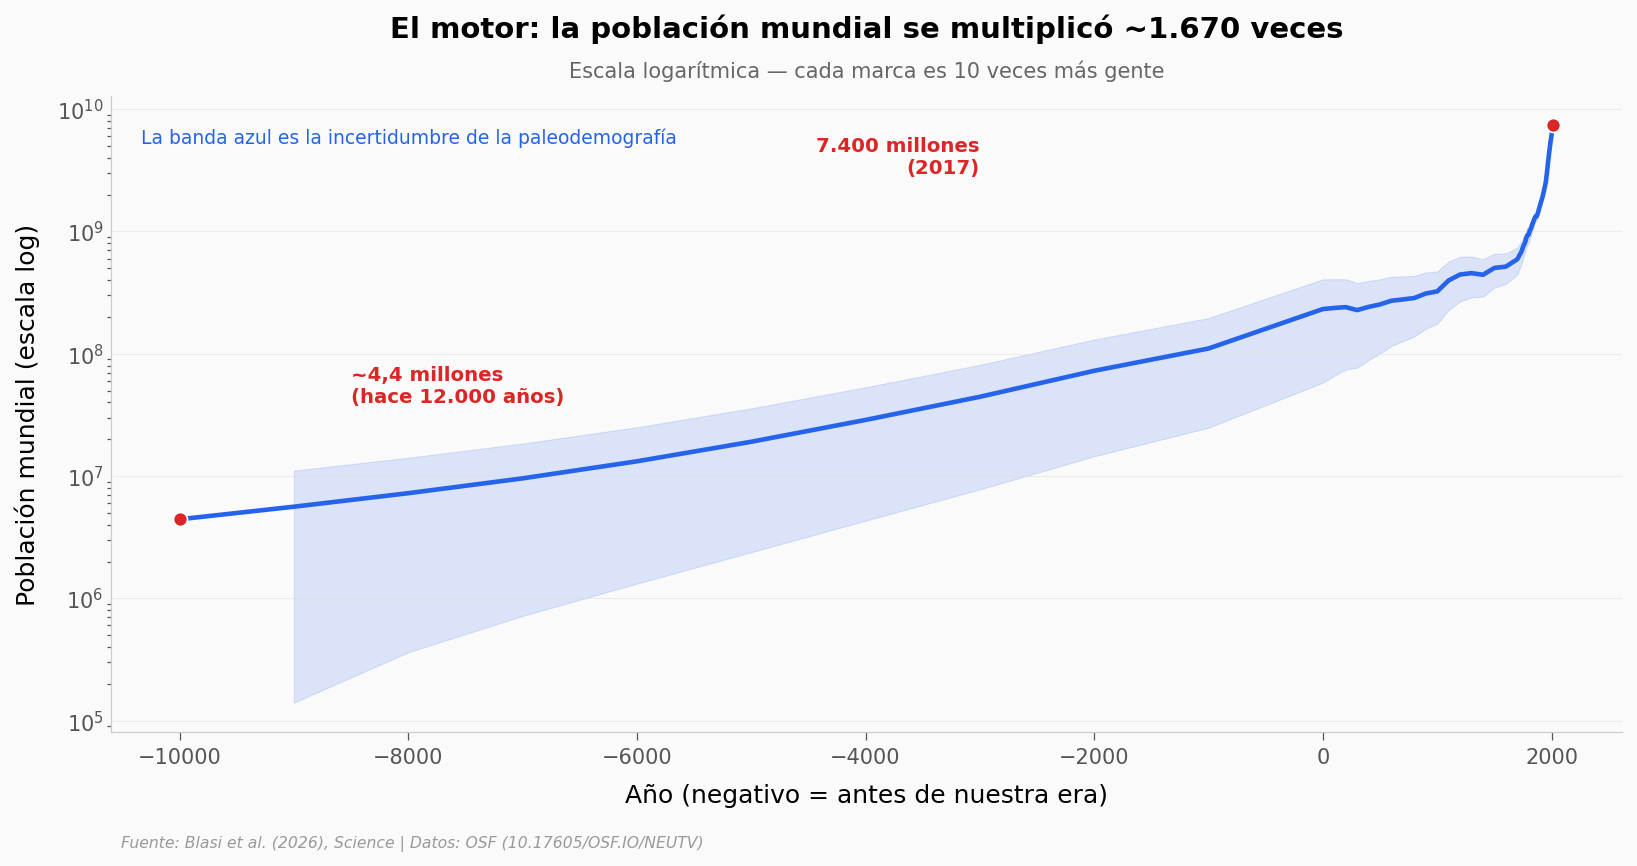

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))
# pop_lower arranca en 0 en -10000; NaN para que el log no se rompa
lower_plot = pop.pop_lower.replace(0, np.nan)
ax.fill_between(pop.year, lower_plot, pop.pop_upper,
                color=COLOR_DATOS, alpha=0.15, zorder=1)
ax.plot(pop.year, pop.pop_mid, color=COLOR_DATOS, linewidth=2.2, zorder=3)
ax.set_yscale('log')

# Anotar dos hitos
ax.scatter([pop.year.iloc[0], pop.year.iloc[-1]],
           [pop.pop_mid.iloc[0], pop.pop_mid.iloc[-1]],
           color=COLOR_ALERTA, s=45, zorder=5, edgecolors='white', linewidths=0.8)
ax.annotate(f'~4,4 millones\n(hace 12.000 años)',
            xy=(pop.year.iloc[0], pop.pop_mid.iloc[0]),
            xytext=(-8500, 4e7), fontsize=9.5, color=COLOR_ALERTA, fontweight='bold')
ax.annotate(f'7.400 millones\n(2017)',
            xy=(pop.year.iloc[-1], pop.pop_mid.iloc[-1]),
            xytext=(-3000, 3e9), fontsize=9.5, color=COLOR_ALERTA, fontweight='bold', ha='right')
ax.text(0.02, 0.95, 'La banda azul es la incertidumbre de la paleodemografía',
        transform=ax.transAxes, fontsize=9, color=COLOR_DATOS, va='top')
ax.set_title('El motor: la población mundial se multiplicó ~1.670 veces',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Escala logarítmica — cada marca es 10 veces más gente',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año (negativo = antes de nuestra era)')
ax.set_ylabel('Población mundial (escala log)')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/poblacion_trayectoria.png', dpi=200, bbox_inches='tight')
plt.show()

## Entonces, ¿cuánto más diverso es el mundo hoy?

Con tanta más gente, uno esperaría muchísimas más lenguas. Pero la cuenta sorprende: de ~5.300 a ~7.500 no es "el doble". Pongámoslo sobre la misma distribución.

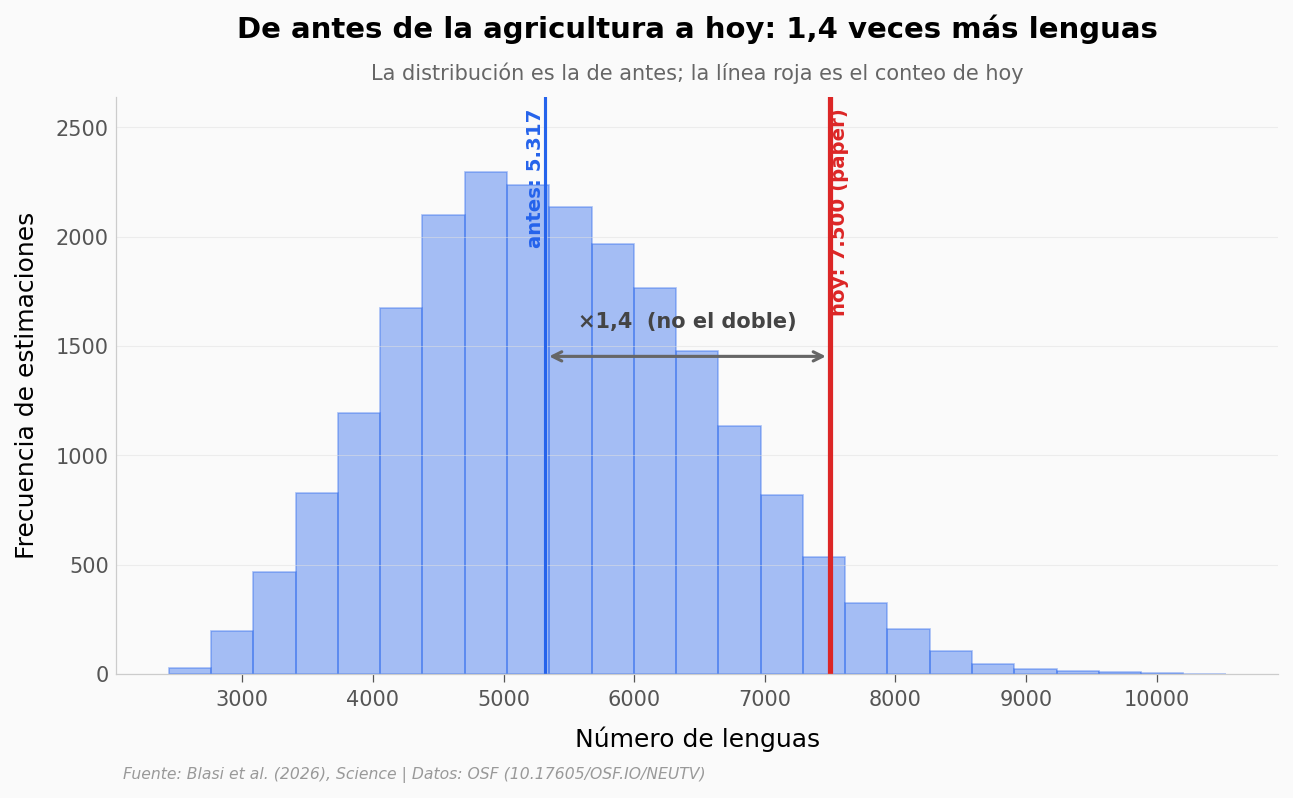

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(data, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(med_global, color=COLOR_DATOS, linewidth=1.5)
ax.text(med_global, y_max*0.98, f'antes: {mil(med_global)}',
        rotation=90, va='top', ha='right', fontsize=9.5, color=COLOR_DATOS, fontweight='bold')
ax.axvline(VALOR_HOY, color=COLOR_ALERTA, linewidth=2.5)
ax.text(VALOR_HOY, y_max*0.98, f'hoy: {mil(VALOR_HOY)} (paper)',
        rotation=90, va='top', ha='left', fontsize=9.5, color=COLOR_ALERTA, fontweight='bold')

ax.annotate('', xy=(VALOR_HOY, y_max*0.55), xytext=(med_global, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((med_global+VALOR_HOY)/2, y_max*0.60, '×1,4  (no el doble)',
        ha='center', fontsize=10, color='#444444', fontweight='bold')

ax.set_title('De antes de la agricultura a hoy: 1,4 veces más lenguas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La distribución es la de antes; la línea roja es el conteo de hoy',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Número de lenguas')
ax.set_ylabel('Frecuencia de estimaciones')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/antes_vs_hoy.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Antes de la domesticación había ~4.500-6.000 lenguas | ✅ | Reprodujimos la mediana global: **5.317** (mitad central 4.540-6.183), dentro del rango del paper. Estimación de modelo, no medición. |
| El rango es robusto entre formas de modelar | ✅ | Los 8 escenarios dan medianas entre **3.980 y 6.053** — todos cerca de la franja del paper. |
| Hoy hay más lenguas que entonces, ~1,4× | ✅ | 7.500 (paper) vs mediana 5.317 = ×1,4. **No** "el doble". |
| La población fue el motor del aumento | ⚠️ | La población pasó de ~4,4 M a ~7.400 M (×1.670). El paper lo modela como **asociación**, no causa demostrada. |
| Hubo una "edad de oro" con decenas de miles de lenguas | ⚠️ | Es el pico del *rise-and-fall* que estima el paper. **No lo reprodujimos** (la curva completa vive en un archivo de 1,4 GB); lo atribuimos al modelo de los autores. |
| La forma temporal dominante es un solo patrón | ✅ | El FPCA —un método que resume en pocas curvas la forma de todas las trayectorias— lo confirma: **PC1 explica 75,5%** de la variación entre trayectorias (PC1+PC2 = 90%). |

> **Limitaciones:** todo son **estimaciones de modelo** con intervalos amplios (la población del año 0 va de 58 M a 406 M según la fuente). El conteo de hoy varía según el criterio (7.500 en el paper, 8.111 en Glottolog crudo). El pico de la "edad de oro" y el rol de los imperios provienen de partes del modelo que estos CSVs no reproducen.

## Ahora tú

Los datos están cargados. Tres preguntas para hurgar:

1. **¿Cuánto cambia la mediana si te quedas solo con los escenarios de "cota estrecha"?** Pista: `eh[eh.Upper == 'tight']['n_languages'].median()`.
2. **¿En qué siglo la población mundial cruzó los mil millones?** Pista: filtra `pop[pop.pop_mid > 1e9].head(1)`.
3. **¿Cuánta incertidumbre añade cada componente del FPCA?** Pista: mira `fpca['individual_variance']` — ¿cuántos componentes hacen falta para el 95%?

In [6]:
# --- EXPERIMENTA AQUI ---
# ¿Cambia el retrato si comparas las dos familias de distribucion?
for dist in ['weibull', 'lognormal']:
    sub = eh[eh.Distribution == dist]['n_languages']
    print(f'{dist:>10}: mediana {mil(sub.median())}  |  '
          f'50% central {mil(sub.quantile(.25))}-{mil(sub.quantile(.75))}')

# Prueba cambiando 'Distribution' por 'Weight' (ponderado vs sin ponderar)
# o por 'Upper' (cota estrecha vs amplia) y observa cuanto se mueve la mediana.

   weibull: mediana 5.093  |  50% central 4.338-5.951
 lognormal: mediana 5.530  |  50% central 4.768-6.392


---

## Fuentes

**Paper**: [The rise and fall of language diversity through the Holocene](https://doi.org/10.1126/science.adx4343)  
*Science, 2026-07-23*

**Datos**: [Code and data for 'The rise and fall of language diversity through the Holocene' (Blasi, Hamilton, Gray, Bowern)](https://doi.org/10.17605/OSF.IO/NEUTV)

**Referencias citadas**: [Glottolog database 4.5 (Hammarstrom, Forkel, Haspelmath, Bank)](https://doi.org/10.5281/ZENODO.5772642)

*13 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com) · código y datos reproducibles en [GitHub](https://github.com/Ciencia-a-Mordiscos/lab).*